# M3: centroid plots

`PLANbeh.md` M3: a centroid plot per subject (each subject collapsed to
their own mean (red, green) point, color-coded by group) and per group (each
group collapsed to one point, the mean of its subjects' centroids), then the
same two plot types for the M2 shape features.

**On "color code the groups":** the dataviz skill's all-pairs scatter color
limit (used already for `plot_feature_space` in M2) caps a single hue-coded
scatter at 3 categories -- past that, distinct colors are no longer
colorblind-safe when any two points can sit side by side. The per-subject
plots below split HC/PD/CVD and HC/protan/deutan into two 3-category panels
for that reason. The group-centroid plots are a handful of large, legended,
well-separated marks rather than a dense cloud, so they carry all 5
categories at once, with marker *shape* doing identity alongside color
(`plotting.CENTROID_MARKERS`) -- consistent with the skill's rule that
identity should never rest on hue alone.

In [1]:
import sys
sys.path.append('../scripts')

import loader
import plotting

df = loader.load_behavioral()

top_level_categories = [
    {'label': 'HC', 'group': 'CTR'},
    {'label': 'PD', 'group': 'PD'},
    {'label': 'CVD', 'group': 'CVD'},
]
subtype_categories = [
    {'label': 'HC', 'group': 'CTR'},
    {'label': 'protan', 'subgroup': 'protan'},
    {'label': 'deutan', 'subgroup': 'deutan'},
]
all_categories = [
    {'label': 'HC', 'group': 'CTR'},
    {'label': 'PD', 'group': 'PD'},
    {'label': 'CVD', 'group': 'CVD'},
    {'label': 'protan', 'subgroup': 'protan'},
    {'label': 'deutan', 'subgroup': 'deutan'},
]

## Per-subject centroids, color-coded by group

Each point is one subject's own mean (red, green) across every click and
session -- the same points `comparisons.compare_groups(unit='subject')`
tests, plotted directly instead of collapsed into a single statistic.

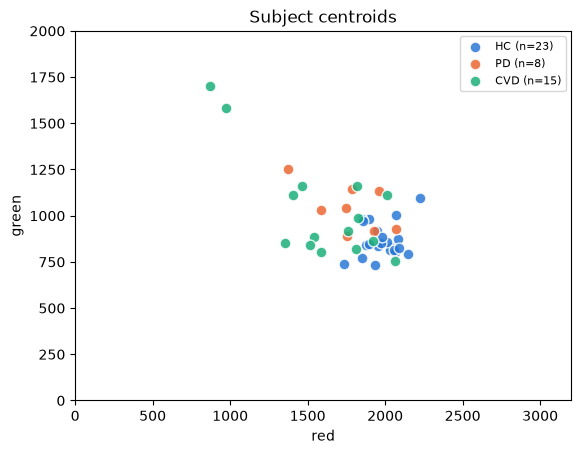

In [2]:
plotting.plot_subject_centroids(df, top_level_categories);

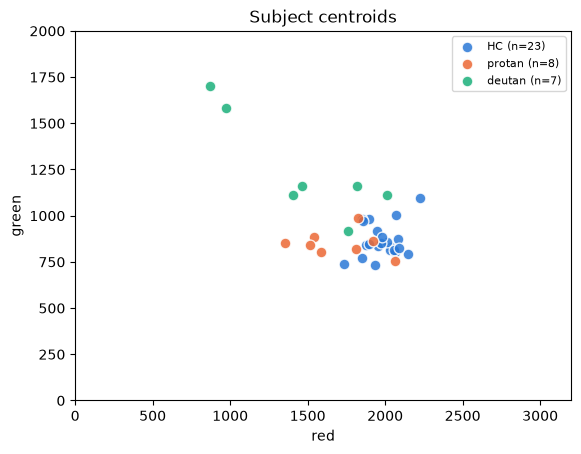

In [3]:
plotting.plot_subject_centroids(df, subtype_categories);

## Group centroids

One marker per group, at the mean of its subjects' centroids, with ±1 SD
error bars showing how spread out those subject centroids are.

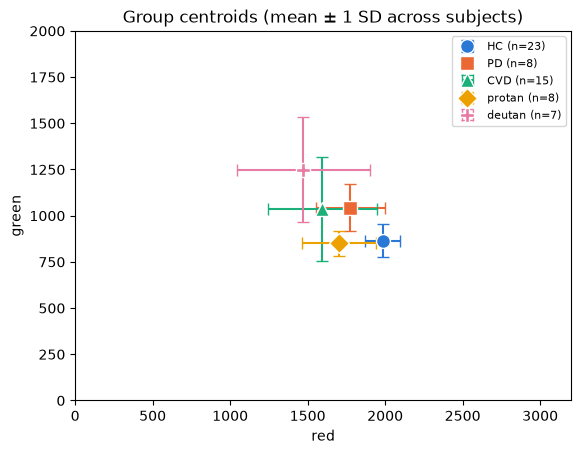

In [4]:
plotting.plot_group_centroids(df, all_categories);

protan sits close to HC on green but pulled left on red; deutan is the
outlier on both axes, with by far the largest spread (SD ~430/280) -- consistent
with M1/M2's finding that deutan is the least homogeneous group in this
dataset. CVD's error bars roughly span the union of protan's and deutan's,
as expected since it is not a distinct group -- it exists as a label only
because protan+deutan is a real clinical category ("has a CVD, any subtype"),
not a third phenotype.

## The same two plot types, for the M2 shape features

The per-subject version is `plot_feature_space` (already built in M2); M3
adds `plot_feature_group_centroids`, its group-centroid analog. All three
pairwise feature combinations, since M2 only found orientation informative
on its own -- worth seeing whether a pairing changes that picture.

In [5]:
from itertools import combinations

feature_pairs = list(combinations(['orientation_deg', 'along_var', 'perp_var'], 2))
feature_pairs

[('orientation_deg', 'along_var'),
 ('orientation_deg', 'perp_var'),
 ('along_var', 'perp_var')]

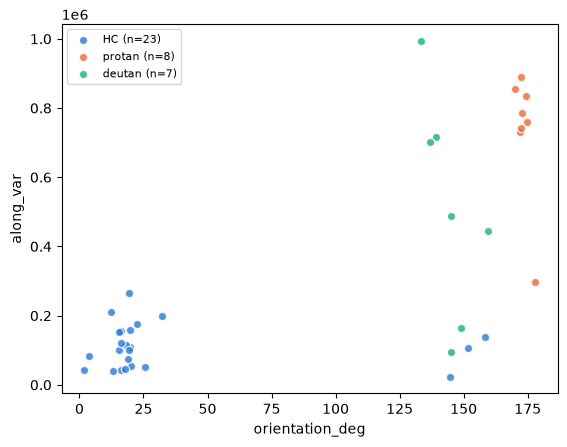

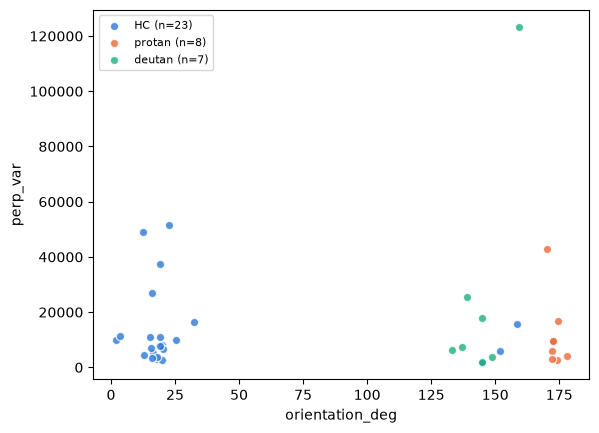

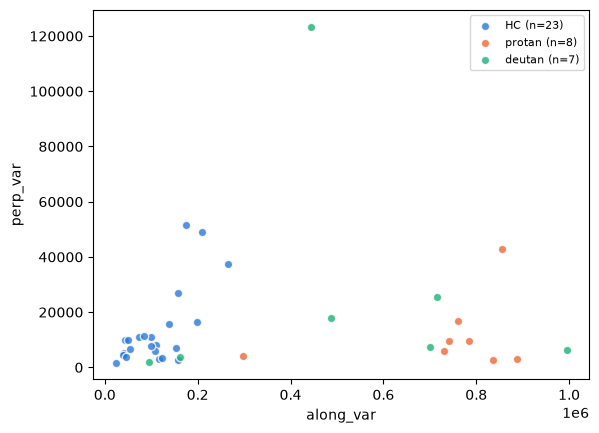

In [6]:
for x_feature, y_feature in feature_pairs:
    plotting.plot_feature_space(df, subtype_categories, x_feature=x_feature, y_feature=y_feature)

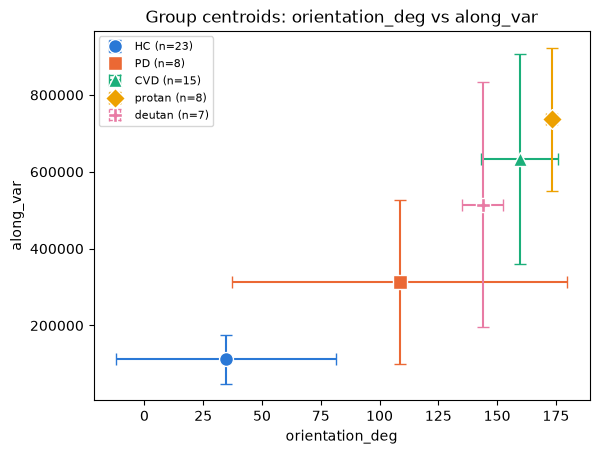

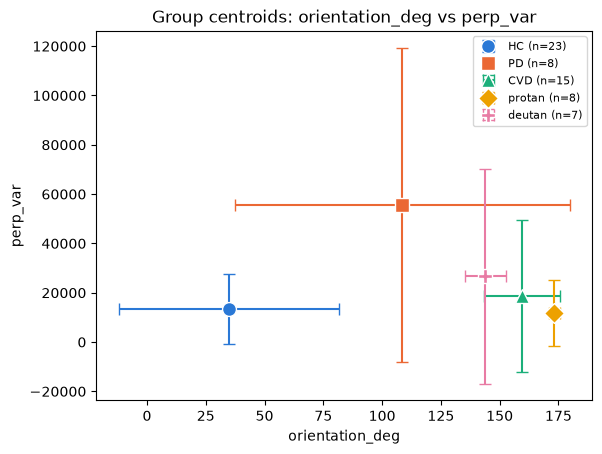

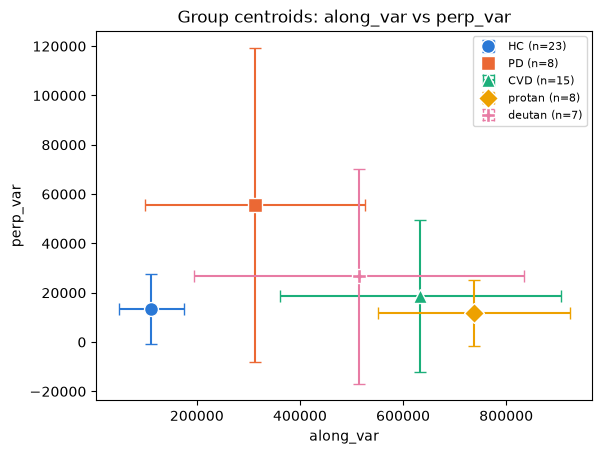

In [7]:
for x_feature, y_feature in feature_pairs:
    plotting.plot_feature_group_centroids(df, all_categories, x_feature=x_feature, y_feature=y_feature)

Consistent with M2's per-feature test: protan and deutan's error bars never
overlap on `orientation_deg` in either pairing (protan mean 173°, SD 2.3 vs.
deutan mean 144°, SD 8.7 -- both far tighter than HC's 35°, SD 47°, which
has no consistent line direction at all). `along_var` and `perp_var` both
have wide, overlapping error bars across every group -- visually confirming
M2's non-significant per-feature tests for those two. Orientation remains
the one shape feature that cleanly separates every group in this dataset,
on both the raw scatter and the centroid view.